# Calculating global pasture inventories using above ground biomass

We want to use an above ground biomass dataset. This gives us the total amount of plant biomass at a given time available for consumption by ruminants. To convert this into available residues, the method will differ depending on what plant species we're looking at:

- For crops: We instead use the SPAM 2010 dataset - see notebooks 2.0 and 3.0
- For everything else: Remove cropped areas, urban areas and woody areas. For the remainder, assume all above ground land biomass is available as residue.
- Arctic circle is removed (everything above 66.5 latitude). See preprocessing/filter_MODIS_arctic.ipynb

### Download and Transform Biomass data

#### Functions

In [15]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt


def open_raster_file(file_path):
    """
    Opens a raster file
    
    Parameters:
        file_path (str): Path to the raster file.

    Returns:
        dataset: The opened rasterio dataset.
    """
    try:
        return rasterio.open(file_path)
    except IOError:
        print(f"Error opening file: {file_path}")
        raise

def resample_raster(src_file, resampling_method=Resampling.bilinear, upscale_factor=0.1):
    """
    Resamples a raster dataset.

    Parameters:
        dataset: Rasterio dataset to resample.
        resampling_method (rasterio.enums.Resampling): Method of resampling.
        upscale_factor (float): Factor to upscale the raster.

    Returns:
        Tuple containing resampled data array and new transform.
    """
    with rasterio.open(src_file) as dataset:
        print("Reading and resampling...")
        data = dataset.read(
            out_shape=(
                dataset.count,
                int(dataset.height * upscale_factor),
                int(dataset.width * upscale_factor)
            ),
            resampling=resampling_method
        )

        print("Scaling the transform...")
        transform = dataset.transform * dataset.transform.scale(
            (dataset.width / data.shape[-1]),
            (dataset.height / data.shape[-2])
        )

        print("Done")
        return data, transform

def write_raster_file(file_path, data, transform, crs, width, height, dtype):
    """
    Writes data to a raster file.

    Parameters:
        file_path (str): Path to save the raster file.
        data: Data array to be written.
        transform: Affine transform for the data.
        crs: Coordinate reference system for the data.
        width (int): Width of the output raster.
        height (int): Height of the output raster.
        dtype: Data type of the output raster.
    """
    with rasterio.open(
        file_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=dtype,
        crs=crs,
        transform=transform,
        nodata=np.nan
    ) as dataset:
        dataset.write(data, 1)

def calculate_areas(lats, pix_width):
    """
    Calculate areas for each latitude in square kilometers.

    Parameters:
        lats (numpy.ndarray): Array of latitudes.
        pix_width (float): Pixel width in degrees.

    Returns:
        numpy.ndarray: Areas of cells in square kilometers.
    """
    a = 6378137
    b = 6356752.3142
    e = np.sqrt(1-(b/a)**2)
    sinlats = np.sin(lats * np.pi/180)
    zm = 1 - e * sinlats
    zp = 1 + e * sinlats
    q = pix_width / 360
    areas_to_equator = np.pi * b**2 * ((2*np.arctanh(e*sinlats) / (2*e) + sinlats / (zp*zm))) / 10**6
    areas_between_lats = np.diff(areas_to_equator)
    return np.abs(areas_between_lats) * q



#### File Path and Constants

In [2]:
# File paths
# INPUTS

#MODIS original
MODIS_LANDCOVER_RASTER = '../../data/processed/MCD12C1-2010-epsg-noarctic.tif'
#MODIS with grasslands with clafficiation confidence > 80%, see Confidence_MODIS.ipynb
#MODIS_LANDCOVER_RASTER = '../../data/processed/MODIS_high_confidence_grasslands.tif'
CARBON_BIOMASS_RASTER = "../../data/processed/aboveground_biomass_carbon_lessthan50.tif"

# OUTPUTS
RESAMPLED_CARBON_BIOMASS_RASTER = "../../data/processed/biomass_resampled.tif"
GRASSLAND_BIOMASS_RASTER = "../../data/processed/biomass_mg_per_ha_from_grassland.tif"
GRASSLAND_BIOMASS_TONNES_RASTER = "../../data/processed/production_pit/biomass_from_grassland_tonnes.tif"
#GRASSLAND_BIOMASS_TONNES_RASTER = "../../data/processed/production_pit/biomass_from_grassland_tonnes_highconfidence.tif"
BIOMASS_RESAMPLED_WARPED_BOUNDS = "../../data/processed/biomass_resampled_warped_bounds.tif"

# CONSTANTS
DOWNSCALE_FACTOR = 18
ABOVE_GROUND_CARBON_MASS_FRACTION_FOR_GRASSES = 0.4473
GRASS_VALUE = 10.0


## Down-sample biomass data

The above-ground biomass carbon raster file is ~2.7GB, making it somewhat unwieldy to work with locally. We don't need it to be this big, as we are otherwise restricted by the size of our MODIS land class data. We'll start by re-sampling the biomass raster to be the same shape as our crop raster.

In [3]:
# Open and process MODIS landcover raster
landcover_dataset = open_raster_file(MODIS_LANDCOVER_RASTER)
landcover_array = landcover_dataset.read(1)

# Open and process carbon biomass uncertainty raster
carbon_biomass_dataset = open_raster_file(CARBON_BIOMASS_RASTER)
carbon_biomass_array = carbon_biomass_dataset.read(1)

# Check for nodata values in carbon biomass uncertainty array
carbon_nodata = carbon_biomass_array == 65536
print(f"Number of nodata values in carbon biomass array: {carbon_nodata.sum()}")

# Re-sample the biomass raster to crop raster (down-scale by a factor of 18)
biomass_arr, biomass_transform = resample_raster(CARBON_BIOMASS_RASTER, Resampling.average, 1/DOWNSCALE_FACTOR)

# Save resampled data
biomass_dataset = rasterio.open(
    RESAMPLED_CARBON_BIOMASS_RASTER,
    "w",
    driver="GTiff",
    height=carbon_biomass_array.shape[0] / DOWNSCALE_FACTOR,
    width=carbon_biomass_array.shape[1] / DOWNSCALE_FACTOR,
    count=1,
    dtype= biomass_arr.dtype,
    crs='+proj=latlong',
    transform=biomass_transform
)


biomass_arr = np.squeeze(biomass_arr)

biomass_dataset.write(biomass_arr, 1)
biomass_dataset.close()



Number of nodata values in carbon biomass array: 0
Reading and resampling...
Scaling the transform...
Done


# Get carbon biomass data for grasslands only

Units need to be multipled by 0,1 to get Mg C/ha (tonnes C / ha) 

Amount represents annual peak of biomass

Extents of grassland are the 'grassland' class in the (MODIS) Land Cover product for 2006

From MODIS user guide: "• Some grassland areas are classified as savannas (sparse forest)." https://lpdaac.usgs.gov/documents/101/MCD12_User_Guide_V6.pdf

What conversion figure to use for carbon from grasses?

https://bg.copernicus.org/articles/15/693/2018/bg-15-693-2018.pdf

0.4473

Note that this is for "oven dry" biomass https://www.fao.org/forestry/17111/en/

In [4]:
print(carbon_biomass_array.max())
print(carbon_biomass_array.shape)
print((carbon_biomass_array.shape[0] * carbon_biomass_array.shape[1]) / (biomass_arr.shape[0] * biomass_arr.shape[1]) )
print(biomass_arr.sum())
print(carbon_biomass_array.sum() / 324.0062068965517)

49.0
(52201, 129600)
324.0062068965517
43787180.0
43782000.572998814


In [5]:
# Warp resampled raster to match landcover raster bounds
# Note: requires GDAL command line tools
# NaN values introduced here when warping

!rio warp "../../data/processed/biomass_resampled.tif" "../../data/processed/biomass_resampled_warped_bounds.tif" --overwrite --dst-crs EPSG:4326 --bounds -180 -90 180 90 --res 0.05 --src-nodata NaN --dst-nodata NaN


In [6]:
landcover_array.mean()

0.45711574074074074

In [7]:
carbon_biomass_warped_dataset = open_raster_file(BIOMASS_RESAMPLED_WARPED_BOUNDS)
carbon_biomass_warped_array = carbon_biomass_warped_dataset.read(1)

# Create a boolean matrix of grass values
grassland = landcover_array == GRASS_VALUE

# Use only carbon biomass which corresponds to True values in the matrix
carbon_biomass_from_grassland_arr = grassland * carbon_biomass_warped_array

# Convert to biomass from carbon biomass
biomass_from_grassland_arr = carbon_biomass_from_grassland_arr / ABOVE_GROUND_CARBON_MASS_FRACTION_FOR_GRASSES

# Save processed grassland biomass data
write_raster_file(
    GRASSLAND_BIOMASS_RASTER,
    biomass_from_grassland_arr,
    carbon_biomass_warped_dataset.transform,
    crs='+proj=latlong',
    width=biomass_from_grassland_arr.shape[1],
    height=biomass_from_grassland_arr.shape[0],
    dtype=biomass_from_grassland_arr.dtype
)



c:\Users\zaris\anaconda3\envs\ag-residues\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in greater
  
c:\Users\zaris\anaconda3\envs\ag-residues\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in less
  


# Summarise

The `biomass_grom_grassland_arr` array is un-projected, i.e. the pixels are lat/lon based. This means the area (in meters) of each pixel will vary based on distance to the equator. The values in each cell are tonnes/hectare, so to get a tonnes production figure, we need to multiply the value of each cell by its area.

In [9]:
# Calculate raster grid cell areas
with open_raster_file(GRASSLAND_BIOMASS_RASTER) as dataset:
    transform = dataset.transform
    pix_width = transform[0]  # Pixel width in degrees
    ulY, lrY = transform[5], transform[5] + transform[4] * dataset.height
    lats = np.linspace(ulY, lrY, dataset.height + 1)

areas_cells = calculate_areas(lats, pix_width)

# Prepare the area grid for multiplication
areagrid = np.transpose(np.matlib.repmat(areas_cells, dataset.width, 1))

# Convert area grid from square km to hectares (x 100) and multiply by our "biomass tonnes per hectare" array
tonnes_of_biomass_from_grass_arr = biomass_from_grassland_arr * areagrid * 100

# Save the final biomass data in tonnes
write_raster_file(
    GRASSLAND_BIOMASS_TONNES_RASTER,
    tonnes_of_biomass_from_grass_arr,
    carbon_biomass_dataset.transform,
    crs='+proj=latlong',
    height=tonnes_of_biomass_from_grass_arr.shape[0],
    width=tonnes_of_biomass_from_grass_arr.shape[1],
    dtype=tonnes_of_biomass_from_grass_arr.dtype
)


In [10]:
#carbon_biomass_warped_dataset.nodatavals[0]
np.count_nonzero(np.isnan(carbon_biomass_warped_array))

5040000

In [11]:
np.count_nonzero(np.isnan(carbon_biomass_warped_array))/np.count_nonzero(~np.isnan(carbon_biomass_warped_array))

0.2413793103448276

In [12]:
print(biomass_from_grassland_arr.shape)
print(areagrid.shape)
print(areagrid.max())
print(areagrid.min())

(3600, 7200)
(3600, 7200)
30.772676396604844
0.013608707649012407


In [13]:
print(np.nansum(tonnes_of_biomass_from_grass_arr)*0.1) # convert units to Mg C/Ha

6327558453.613019


### Visualize Biomass

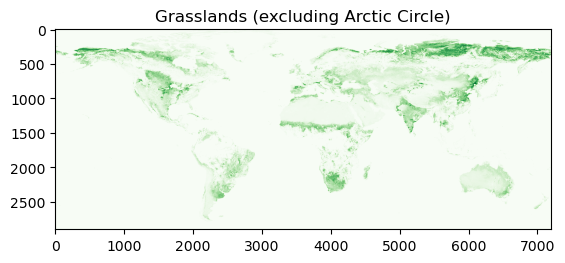

In [16]:
plt.imshow(biomass_arr, cmap='Greens')
plt.title('Grasslands (excluding Arctic Circle)')
plt.show()

In [17]:
print('Total Crude Protein (megatonnes)')
print('less than 50:', ((np.nansum(tonnes_of_biomass_from_grass_arr)*0.1)/1000000) * 9.6/100)

print('\n')

print('Total RME (petajoules)')

print('less than 50:', ((np.nansum(tonnes_of_biomass_from_grass_arr)*0.1)/1000000) * 8.9)

Total Crude Protein (megatonnes)
less than 50: 607.4456115468498


Total RME (petajoules)
less than 50: 56315.27023715587
